In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**0단계:설치 & 압축 풀기**

In [9]:
!pip install ultralytics easyocr
import zipfile
zipfile.ZipFile("/content/drive/MyDrive/dataset/dataset.zip").extractall("/content/raw")

**1단계: VOC(xml) → YOLO 변환 + train/val 자동 분할**

In [10]:
import xml.etree.ElementTree as ET
from pathlib import Path
import random, shutil

RAW = Path("/content/raw")          # 압축 푼 곳
OUT = Path("/content/dataset")      # YOLO용 폴더
random.seed(42)

for sub in ["images/train","images/val","labels/train","labels/val"]:
    (OUT/sub).mkdir(parents=True, exist_ok=True)

def find_image(xml_path):
    for ext in [".jpg",".jpeg",".png",".JPG",".PNG"]:
        p = xml_path.with_suffix(ext)
        if p.exists(): return p
    return None

def convert(xml_path):
    root = ET.parse(xml_path).getroot()
    W = int(root.find("size/width").text)
    H = int(root.find("size/height").text)
    lines = []
    for obj in root.findall("object"):
        if obj.findtext("name") != "paper": continue
        b = obj.find("bndbox")
        x1,y1 = int(b.findtext("xmin")), int(b.findtext("ymin"))
        x2,y2 = int(b.findtext("xmax")), int(b.findtext("ymax"))
        cx,cy = (x1+x2)/2/W, (y1+y2)/2/H
        w,h   = (x2-x1)/W, (y2-y1)/H
        lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
    return lines

xmls = list(RAW.rglob("*.xml"))
random.shuffle(xmls)
n_val = int(len(xmls)*0.2)          # 20% 검증용

cnt = {"train":0,"val":0}
for i, xml in enumerate(xmls):
    img = find_image(xml)
    if img is None:
        print("이미지 없음:", xml.name); continue
    split = "val" if i < n_val else "train"
    shutil.copy(img, OUT/f"images/{split}/{img.name}")
    (OUT/f"labels/{split}/{xml.stem}.txt").write_text("\n".join(convert(xml)))
    cnt[split]+=1

print("분할 결과:", cnt)

# data.yaml 생성
(OUT/"data.yaml").write_text(
"""path: /content/dataset
train: images/train
val: images/val
names:
  0: paper
""")
print("data.yaml 생성 완료")


분할 결과: {'train': 146, 'val': 36}
data.yaml 생성 완료


**2단계: 학습**

In [11]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")                  # 가벼운 모델로 시작
model.train(data="/content/dataset/data.yaml",
            epochs=50, imgsz=640, batch=8)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ca0dc287c80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

**3단계: 테스트(정확도 평가)**

In [12]:
model = YOLO("/content/runs/detect/train/weights/best.pt")
metrics = model.val()                       # val셋으로 mAP 측정
print("mAP50:", metrics.box.map50)          # 1에 가까울수록 좋음


Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 652.3±657.1 MB/s, size: 4187.1 KB)
val: Scanning /content/dataset/labels/val.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 3.1Mit/s 0.0s
val: /content/dataset/images/val/20260616_103717.jpg: corrupt JPEG restored and saved
val: /content/dataset/images/val/20260616_111749.jpg: corrupt JPEG restored and saved
val: /content/dataset/images/val/20260616_111756.jpg: corrupt JPEG restored and saved
val: /content/dataset/images/val/20260616_111815.jpg: corrupt JPEG restored and saved
val: /content/dataset/images/val/20260616_111843.jpg: corrupt JPEG restored and saved
val: /content/dataset/images/val/20260616_111901.jpg: corrupt JPEG restored and saved
val: /content/dataset/images/val/20260616_111927.jpg: corrupt JPEG restored and saved
val: /content/dataset/im


image 1/1 /content/dataset/images/val/KakaoTalk_20260617_190856325_19.jpg: 640x384 1 paper, 43.6ms
Speed: 3.5ms preprocess, 43.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)


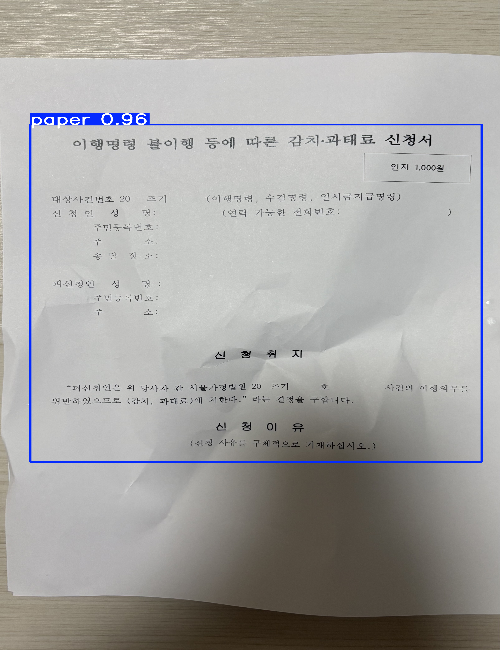


image 1/1 /content/dataset/images/val/doc7_6.jpg: 640x384 1 paper, 8.1ms
Speed: 3.0ms preprocess, 8.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)


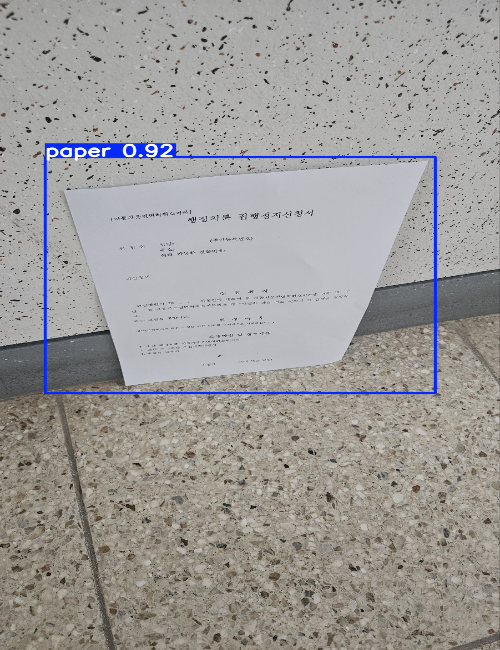


image 1/1 /content/dataset/images/val/doc10_2.jpg: 384x640 1 paper, 58.3ms
Speed: 4.7ms preprocess, 58.3ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


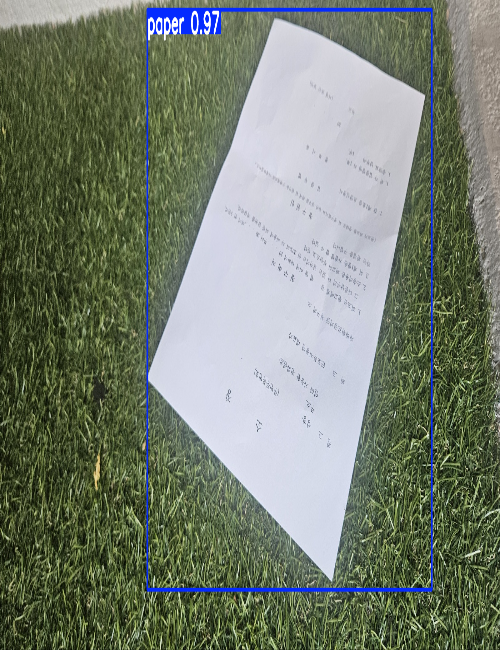

In [14]:
from google.colab.patches import cv2_imshow
import cv2, glob
for p in glob.glob("/content/dataset/images/val/*")[:3]:
    res = model(p)[0]
    cv2_imshow(cv2.resize(res.plot(), (500,650)))   # 박스 그려진 결과


**4단계: 검출 → 크롭 → EasyOCR 연결**

In [15]:
import easyocr, json, numpy as np
reader = easyocr.Reader(['ko','en'], gpu=True)

def full_pipeline(image_path, doc_id):
    img = cv2.imread(image_path)
    res = model(image_path)[0]
    if len(res.boxes)==0:                   # 종이 못 찾으면 원본
        crop = img
    else:
        # 가장 신뢰도 높은 박스 선택
        b = res.boxes[res.boxes.conf.argmax()].xyxy[0].cpu().numpy().astype(int)
        x1,y1,x2,y2 = b
        crop = img[y1:y2, x1:x2]
    text = "\n".join(r[1] for r in reader.readtext(crop, paragraph=True))
    return {"doc_id":doc_id,"input_type":"image","ocr_text":text,
            "extracted_info":{},"severity":{},"easy_summary":"","action_guide":[]}

r = full_pipeline("/content/dataset/images/val/" +
                  Path(glob.glob("/content/dataset/images/val/*")[0]).name, "doc_001")
print(json.dumps(r, ensure_ascii=False, indent=2))


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Complete
image 1/1 /content/dataset/images/val/KakaoTalk_20260617_190856325_19.jpg: 640x384 1 paper, 7.5ms
Speed: 2.5ms preprocess, 7.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)
{
  "doc_id": "doc_001",
  "input_type": "image",
  "ocr_text": "이행명령 불이행 둥에 따른  감치 과태료  신청서\n인지 1,000원\n대상사건번호 20 즈기 신 청 인   성 명: 주민등록번호 : 주 소: 송 달   장 소:\n(이행명령 수검명령 , 일시금지급명령 ) (연락   가능한   전화번호:\n피신청인 성   명 주민등록번호 : 주 소:\n신   청   취   지\n66\n'피신청인은 위 당사자  간 서울가정법원 20 즈기\n호\n사건의 이행의무릎\n위반하엿으므로 (감치 ,  과태료)에  처한다 .\"  라는  결정올 구합니다 .\n신 청 이 유\n(신청 사유름 구체적으로 기재하십시오. )",
  "extracted_info": {},
  "severity": {},
  "easy_summary": "",
  "action_guide": []
}
